# Part B — 01 Target Creation

## Predicting High-Impact AI Patents

The objective of Part B is to determine whether patent metadata can help
identify AI patents that are likely to become highly influential.

Patent impact is measured using forward citations.

To make patents comparable, forward citations are measured within a fixed
24-month period after the patent grant date.

Only patents with a complete 24-month citation observation period are used
for model development.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent

PROCESSED_DIR = ROOT / "Data" / "processed"
RAW_DIR = ROOT / "Data" / "raw"

TABLES_DIR = ROOT / "Outputs" / "tables"
FIGURES_DIR = ROOT / "Outputs" / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = (
    PROCESSED_DIR /
    "02_clean_patents.parquet"
)

print("Dataset:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Dataset: /Users/janakdobariya/Bramha/NLP_Engineering/BA/ai_patent_business_analytics/Data/processed/02_clean_patents.parquet
Exists: True


In [2]:
df = pd.read_parquet(DATA_PATH)

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])

df.head()

Rows: 80,566
Columns: 23


,publication_number,application_number,family_id,publication_date,filing_date,grant_date,priority_date,grant_year,title,abstract,...,assignee_country,cpc_count,primary_ai_cpc,cpc_group,backward_citation_count,title_word_count,abstract_word_count,claims_text_length,claims_word_count,filing_to_grant_days
0,US-10881345-B2,US-201715611953-A,59030779,2021-01-05,2017-06-02,2021-01-05,2016-06-03,2021,Method and system for estimation of stress of ...,A system and method for determining a stress l...,...,IN,17,G06N3/0499,G06N3,8,12.0,136.0,8263,1277,1313.0
1,US-10881348-B2,US-201715400287-A,49380436,2021-01-05,2017-01-06,2021-01-05,2012-02-27,2021,System and method for gathering and analyzing ...,Systems and methods for measuring biologically...,...,US,18,G06N20/00,G06N20,744,18.0,145.0,9630,1497,1460.0
2,US-10881463-B2,US-201715690436-A,65436394,2021-01-05,2017-08-30,2021-01-05,2017-08-30,2021,Optimizing patient treatment recommendations u...,Patient treatment may be optimized using Recur...,...,US,13,G06N3/044,G06N3,22,15.0,125.0,11398,1686,1224.0
3,US-10881964-B1,US-201816130854-A,74045007,2021-01-05,2018-09-13,2021-01-05,2018-09-13,2021,Automated detection of emergent behaviors in i...,Various aspects of the subject technology rela...,...,US,17,G06N3/045,G06N3,5,12.0,155.0,9597,1393,845.0
4,US-10882488-B2,US-201816048797-A,63207881,2021-01-05,2018-07-30,2021-01-05,2017-07-28,2021,Hardware and software mechanisms on autonomous...,An autonomous robot vehicle includes a front s...,...,US,110,G06N20/00,G06N20,21,10.0,100.0,6702,993,890.0


In [4]:
CITATION_DATA_END = pd.Timestamp("2026-04-21")

OBSERVATION_MONTHS = 24

LATEST_ELIGIBLE_GRANT = (
    CITATION_DATA_END
    - pd.DateOffset(months=OBSERVATION_MONTHS)
)

print(
    "Latest eligible grant date:",
    LATEST_ELIGIBLE_GRANT.date()
)

Latest eligible grant date: 2024-04-21


In [5]:
model_df = df[
    df["grant_date"] <= LATEST_ELIGIBLE_GRANT
].copy()

print(
    "Full Part A dataset:",
    f"{len(df):,}"
)

print(
    "Eligible Part B patents:",
    f"{len(model_df):,}"
)

Full Part A dataset: 80,566
Eligible Part B patents: 49,556


In [6]:
model_df["grant_year"].value_counts().sort_index()

grant_year
2021    11246
2022    15219
2023    17597
2024     5494
Name: count, dtype: int64

In [7]:
FORWARD_PATH = (
    RAW_DIR /
    "forward_citations_24m.csv"
)

forward_df = pd.read_csv(
    FORWARD_PATH
)

print(
    "Forward citation records:",
    f"{len(forward_df):,}"
)

forward_df.head()

Forward citation records: 49,556


,publication_number,grant_date,forward_citations_24m
0,US-10881345-B2,2021-01-05,0
1,US-10881348-B2,2021-01-05,1
2,US-10881463-B2,2021-01-05,1
3,US-10881964-B1,2021-01-05,15
4,US-10882488-B2,2021-01-05,1


In [8]:
forward_df[
    "forward_citations_24m"
].describe()

count    49556.000000
mean         1.359149
std          4.435135
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        316.000000
Name: forward_citations_24m, dtype: float64

In [9]:
print(
    "Patents with zero forward citations:",
    (
        forward_df["forward_citations_24m"]
        == 0
    ).sum()
)

print(
    "Patents with at least one forward citation:",
    (
        forward_df["forward_citations_24m"]
        > 0
    ).sum()
)

Patents with zero forward citations: 28996
Patents with at least one forward citation: 20560


In [10]:
model_df = model_df.merge(
    forward_df[
        [
            "publication_number",
            "forward_citations_24m"
        ]
    ],
    on="publication_number",
    how="left"
)

In [11]:
print("Rows after merge:", f"{len(model_df):,}")

print(
    "Missing forward citation values:",
    model_df[
        "forward_citations_24m"
    ].isna().sum()
)

Rows after merge: 49,556
Missing forward citation values: 0


In [12]:
model_df[
    "forward_citations_24m"
].describe(
    percentiles=[
        .25,
        .50,
        .75,
        .90,
        .95
    ]
)

count    49556.000000
mean         1.359149
std          4.435135
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
90%          3.000000
95%          6.000000
max        316.000000
Name: forward_citations_24m, dtype: float64

In [13]:
citation_threshold = (
    model_df[
        "forward_citations_24m"
    ]
    .quantile(0.75)
)

print(
    "75th percentile:",
    citation_threshold
)

75th percentile: 1.0


In [15]:
model_df["high_impact"] = (
    model_df["forward_citations_24m"] > citation_threshold
).astype(int)

In [16]:
target_summary = pd.DataFrame({
    "count": model_df["high_impact"].value_counts().sort_index(),
    "percent": (
        model_df["high_impact"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
})

target_summary

,count,percent
high_impact,,
0,37867,76.41
1,11689,23.59


In [17]:
model_df["impact_label"] = model_df["high_impact"].map({
    0: "Normal Impact",
    1: "High Impact"
})

model_df[
    [
        "publication_number",
        "forward_citations_24m",
        "high_impact",
        "impact_label"
    ]
].head(10)

,publication_number,forward_citations_24m,high_impact,impact_label
0,US-10881345-B2,0,0,Normal Impact
1,US-10881348-B2,1,0,Normal Impact
2,US-10881463-B2,1,0,Normal Impact
3,US-10881964-B1,15,1,High Impact
4,US-10882488-B2,1,0,Normal Impact
5,US-10882522-B2,2,1,High Impact
6,US-10883106-B2,0,0,Normal Impact
7,US-10883475-B2,0,0,Normal Impact
8,US-10883842-B2,1,0,Normal Impact
9,US-10883844-B2,8,1,High Impact


In [18]:
target_by_year = (
    model_df
    .groupby("grant_year")
    ["high_impact"]
    .agg(["count", "sum", "mean"])
)

target_by_year["high_impact_percent"] = (
    target_by_year["mean"] * 100
).round(2)

target_by_year

,count,sum,mean,high_impact_percent
grant_year,,,,
2021,11246,3178,0.282589,28.26
2022,15219,3866,0.254025,25.40
2023,17597,3681,0.209183,20.92
2024,5494,964,0.175464,17.55


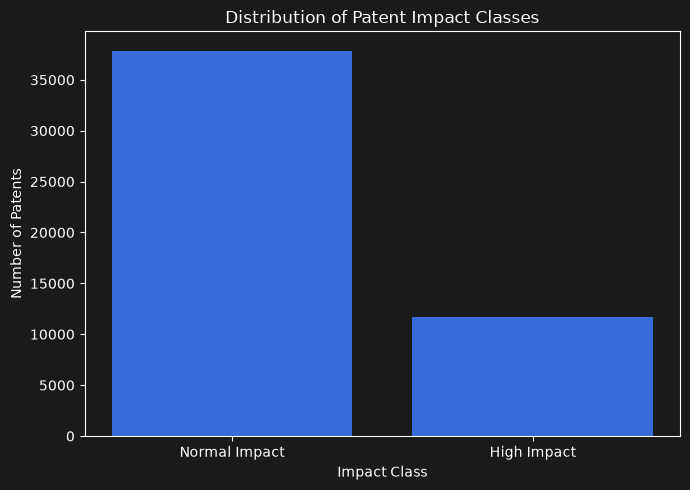

In [19]:
target_counts = (
    model_df["impact_label"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

plt.bar(
    target_counts.index,
    target_counts.values
)

plt.title("Distribution of Patent Impact Classes")
plt.xlabel("Impact Class")
plt.ylabel("Number of Patents")

plt.tight_layout()
plt.show()

In [20]:
print(
    "Missing forward citations:",
    model_df["forward_citations_24m"].isna().sum()
)

print(
    "Missing target:",
    model_df["high_impact"].isna().sum()
)

print(
    "Duplicate patents:",
    model_df["publication_number"].duplicated().sum()
)

Missing forward citations: 0
Missing target: 0
Duplicate patents: 0


In [21]:
TARGET_PATH = (
    PROCESSED_DIR /
    "01_part_b_target_dataset.parquet"
)

model_df.to_parquet(
    TARGET_PATH,
    index=False
)

print("Saved:")
print(TARGET_PATH)
print("Shape:", model_df.shape)

Saved:
/Users/janakdobariya/Bramha/NLP_Engineering/BA/ai_patent_business_analytics/Data/processed/01_part_b_target_dataset.parquet
Shape: (49556, 26)
